In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import fmatoolbox as fma
import sys
import pathlib
sys.path.append(str(pathlib.Path.cwd().parent.parent))
import ISRUtilities as isru
batch_file = '/mnt/hubel-data-103/Pietro/InfraSlowNRPaper/Data/IS_intervals.batch'

In [ ]:
s0 = [1,3,4,7,9,14,15]
s1 = [3,6,7,10,13]
events = [2,11]
fma.analysis.jointPETH((s0,s1),events,bin=1,n_bins=3,return_peths=True) # limits=[-1.5,1.5],

In [2]:
session = fma.data.readBatchFile(batch_file)[0][15]
print(session)
events = isru.loadHpcPfcEvents(session,names=['ripples','deltaWaves','down','spindles'])

/mnt/hubel-data-139/karadoc/Rat004_20240227/Rat004_20240227.xml


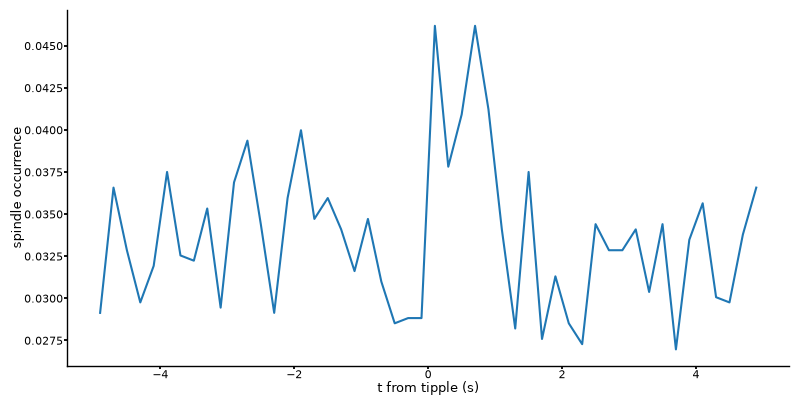

In [3]:
_, t, m = fma.analysis.PETH(events['spindles'],events['ripples'],limits=[-5,5],bin=0.2)
fig, ax = fma.plotting.makeFigure()
ax[0].plot(t,m)
ax[0].set(xlabel='t from tipple (s)',ylabel='spindle occurrence');

In [4]:
joint, null, diff, t0, t1, peth0, peth1 = fma.analysis.jointPETH((events['ripples'],events['spindles']),events['down'],bin=0.01,limits=(-2,2),smooth=2,return_peths=True)

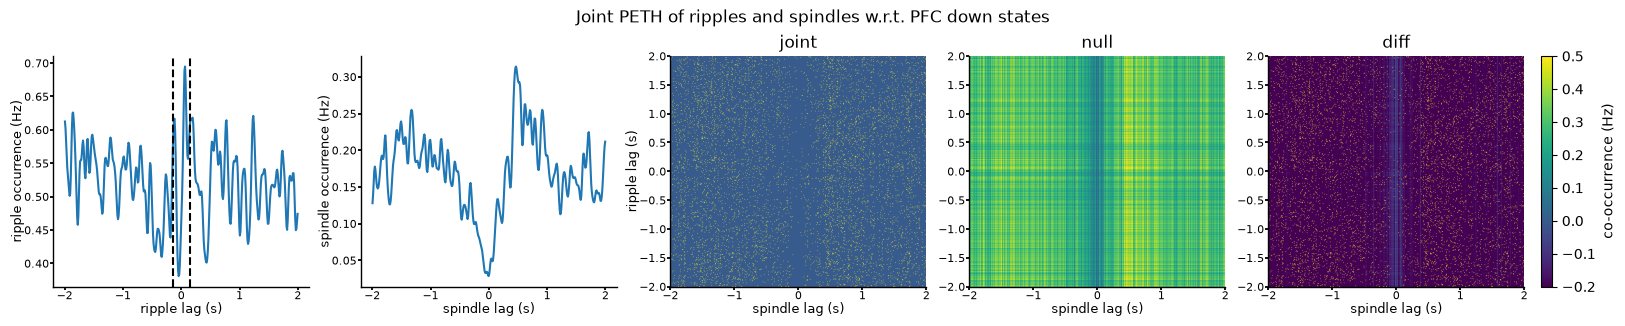

In [5]:
fig, ax = fma.plotting.makeFigure('Joint PETH of ripples and spindles w.r.t. PFC down states',n=(1,5),size=(41,8))

ax[0].plot(t0,peth0)
[ax[0].axvline(v,color='k',ls='--') for v in [-0.15,0.15]]
ax[1].plot(t1,peth1)
ax[1].set(ylabel='spindle occurrence (Hz)')

vmin = -.2
vmax = .5
fma.plotting.plotColorMap(joint,x=t1,y=t0,vmin=vmin,vmax=vmax,ax=ax[2])
ax[2].set(ylabel='ripple lag (s)',title='joint')
fma.plotting.plotColorMap(null,x=t1,y=t0,vmin=vmin,vmax=vmax,ax=ax[3])
ax[3].set(title='null')
h = fma.plotting.plotColorMap(diff,x=t1,y=t0,vmin=vmin,vmax=vmax,ax=ax[4],bar='co-occurrence (Hz)')
ax[4].set(title='diff'); fma.plotting.setProp(ax,xlabel='spindle lag (s)')
ax[0].set(xlabel='ripple lag (s)',ylabel='ripple occurrence (Hz)');

see oscillations

In [15]:
def loadExamples(session,channel=None):
    R = fma.regions.regions(session,load_spikes=False)
    events = isru.loadHpcPfcEvents(session)

    regs = ['hpc','pfc','pfc']
    names = ['ripples','spindles','deltaWaves']
    if channel is None:
        channel = {names[i]: R.channels(r)[8] for i, r in enumerate(regs)}
    limits = [[-1,1],[-1,1],[-5,5]]
    skip = [100,100,600]

    rng = np.random.default_rng()
    examples = {}
    for i, e in enumerate(events):
        print(f'{e}: {channel[e]}')

        intervals = np.sort(rng.choice(events[e],size=5,replace=False,shuffle=False)[:,None],axis=0) + limits[i]
        ex = fma.data.loadWideband(session,intervals=intervals,channels=channel[e],skip=skip[i],cat=False,trim=True)
        examples[e] = {}
        examples[e]['data'] = np.hstack(ex[0])
        #examples[e]['t'] = np.stack(ex[1],axis=1)
        examples[e]['t'] = np.tile(np.linspace(limits[i][0],limits[i][1],len(examples[e]['data']))[:,None],(1,examples[e]['data'].shape[1]))

    return examples

In [18]:
#examples = loadExamples(session,channel={'ripples': 115, 'spindles': 159, 'deltaWaves': 159}) # Rat 12
examples = loadExamples(session,channel={'ripples': 74, 'spindles': 35, 'deltaWaves': 35}) # perceval

ripples: 74
deltaWaves: 35
spindles: 35


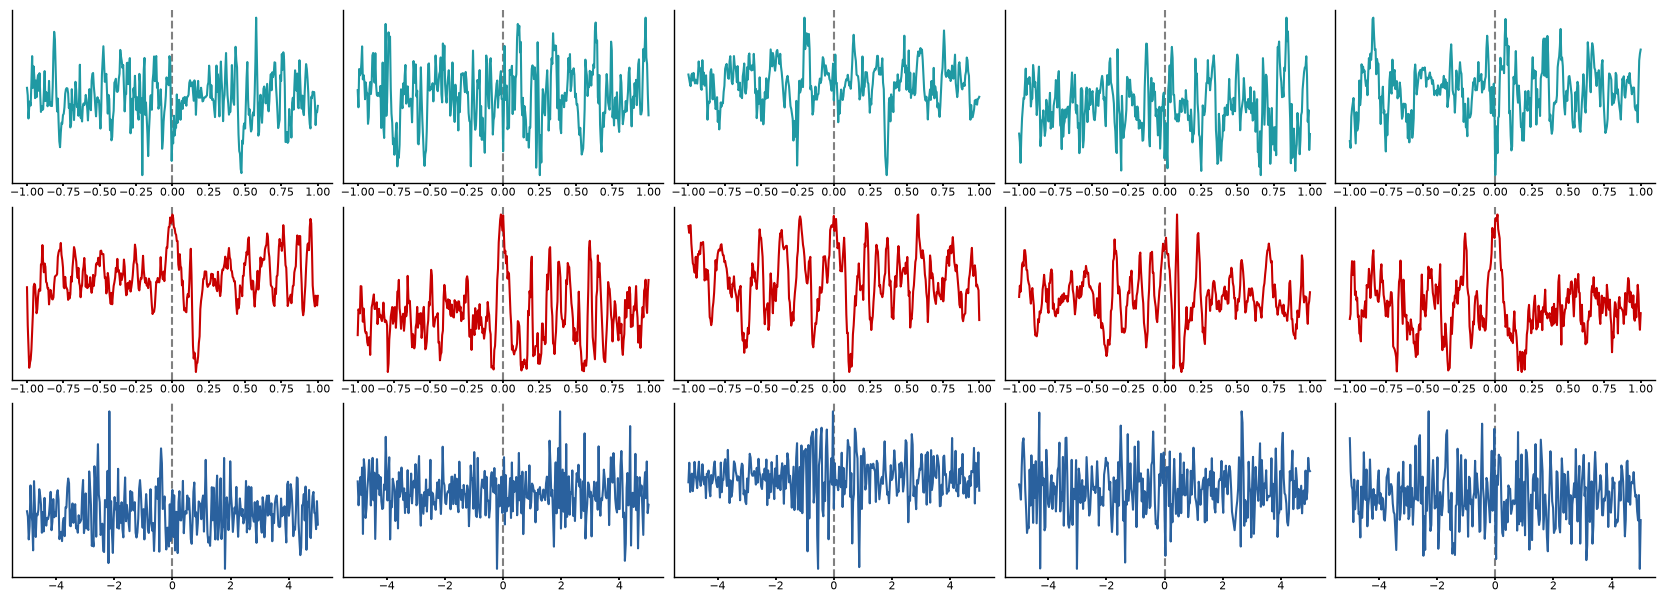

In [19]:
fig, ax = fma.plotting.makeFigure(n=(3,5),size=(42,15))
for j, e in enumerate(examples):
    for i in range(examples[e]['data'].shape[1]):
        ax[j,i].axvline(0,color='gray',ls='--'); ax[j,i].set(yticks=[])
        ax[j,i].plot(examples[e]['t'][:,i],examples[e]['data'][:,i],color=isru.paperColors(e))